In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from ripser import ripser
from persim import plot_diagrams
from sklearn.ensemble import RandomForestRegressor

# =========================================================
# PARAMÈTRES GLOBAUX
# =========================================================

# Mets BEAUCOUP plus de tickers pour avoir une vraie structure
tickers = [
    "AAPL","MSFT","GOOGL","AMZN","META","NVDA","TSLA","NFLX","JPM","BAC",
    "XOM","CVX","KO","PEP","INTC","AMD","CSCO","ORCL","DIS","IBM"
]

START_DATE = "2015-01-01"
END_DATE   = "2024-01-01"

WINDOW_CORR = 120   # fenêtre pour la corrélation
ALPHA       = 0.1
J_DIFF      = 5
FORWARD_H   = 5     # horizon de prédiction : 5 jours

# =========================================================
# 1. TÉLÉCHARGEMENT DES DONNÉES
# =========================================================

data = yf.download(tickers, start=START_DATE, end=END_DATE)["Close"]
prices = data
returns = np.log(prices).diff().dropna()

N = len(tickers)


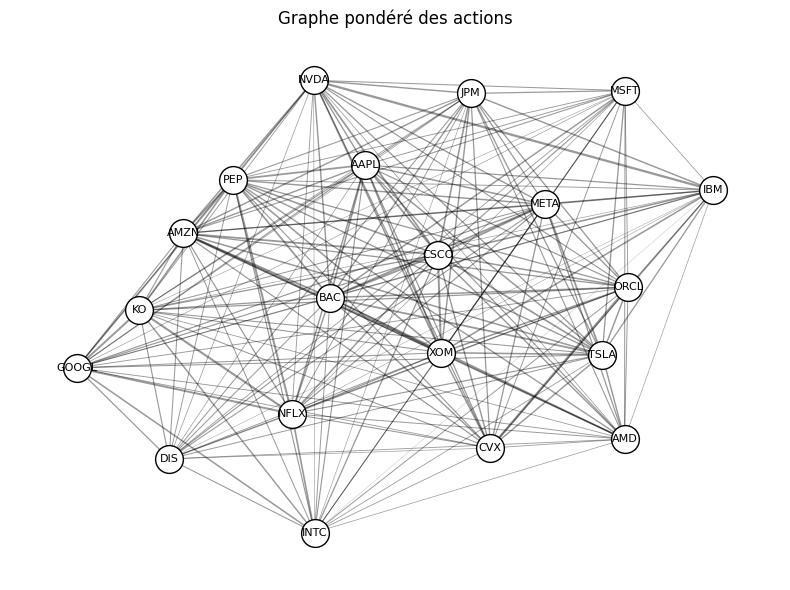

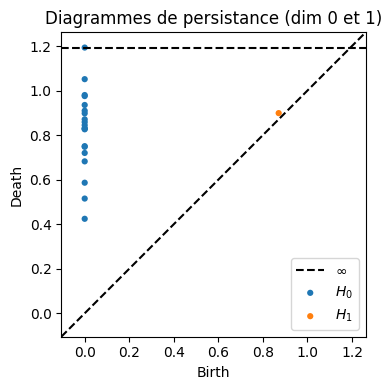

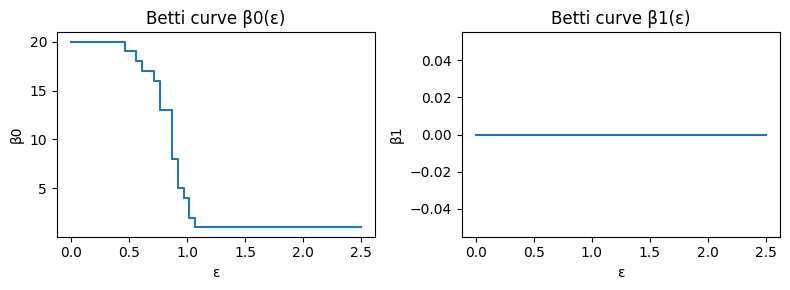

R² (test) horizon 5 jours : -0.20653668360925215
            date ticker     resid  topo_0     topo_1    topo_2  topo_3  \
42755 2023-12-21    AMD  0.005865    19.0  18.502706  1.237669     5.0   
42756 2023-12-21   CSCO  0.003732    19.0  18.502706  1.237669     5.0   
42757 2023-12-21   ORCL -0.002096    19.0  18.502706  1.237669     5.0   
42758 2023-12-21    DIS  0.016911    19.0  18.502706  1.237669     5.0   
42759 2023-12-21    IBM -0.004150    19.0  18.502706  1.237669     5.0   

         topo_4    topo_5    y_true    y_pred  
42755  0.079698  0.031054  0.010801 -0.012224  
42756  0.079698  0.031054 -0.004070 -0.012224  
42757  0.079698  0.031054  0.017043 -0.012224  
42758  0.079698  0.031054 -0.023938 -0.012224  
42759  0.079698  0.031054 -0.017352 -0.012224  


In [7]:
# =========================================================
# 2. FONCTIONS UTILES
# =========================================================

def compute_laplacian(corr_matrix: np.ndarray) -> np.ndarray:
    W = np.abs(corr_matrix.copy())
    np.fill_diagonal(W, 0.0)
    degrees = W.sum(axis=1)
    D = np.diag(degrees)
    L = D - W
    return L, W

def laplacian_diffusion(x: np.ndarray, L: np.ndarray,
                        alpha: float, n_steps: int) -> np.ndarray:
    h = x.copy()
    for _ in range(n_steps):
        h = h - alpha * (L @ h)
    return h

def topo_features_from_corr(corr_matrix: np.ndarray, maxdim: int = 1) -> np.ndarray:
    Dmat = np.sqrt(2.0 * (1.0 - corr_matrix))
    np.fill_diagonal(Dmat, 0.0)

    res = ripser(Dmat, distance_matrix=True, maxdim=maxdim)
    dgms = res["dgms"]

    feats = []
    for dim in range(maxdim + 1):
        dgm = dgms[dim]
        finite_mask = np.isfinite(dgm[:, 1])
        dgm_finite = dgm[finite_mask]

        if dgm_finite.shape[0] == 0:
            feats.extend([0.0, 0.0, 0.0])
            continue

        lifetimes = dgm_finite[:, 1] - dgm_finite[:, 0]
        feats.extend([
            float(len(lifetimes)),        # nb de points
            float(lifetimes.sum()),       # persistance totale
            float(lifetimes.max()),       # max persistance
        ])
    return np.array(feats, dtype=float)

# =========================================================
# 3. BLOC A : VISU “SUPER GRAPHS” SUR UN JOUR DONNÉ
# =========================================================

# On prend un jour assez tard pour avoir la fenêtre complète
k_demo = WINDOW_CORR + 200
window_demo = returns.iloc[k_demo - WINDOW_CORR : k_demo]
R_demo = window_demo.corr().values

L_demo, W_demo = compute_laplacian(R_demo)
x_demo = returns.iloc[k_demo].values
h_demo = laplacian_diffusion(x_demo, L_demo, alpha=ALPHA, n_steps=J_DIFF)
e_demo = x_demo - h_demo

# ---- Graphe pondéré de stocks
G = nx.from_numpy_array(W_demo)
mapping = {i: tickers[i] for i in range(N)}
G = nx.relabel_nodes(G, mapping)

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42, k=0.3)
edges, weights = zip(*nx.get_edge_attributes(G,'weight').items())

nx.draw_networkx_nodes(G, pos, node_size=400, node_color="white", edgecolors="black")
nx.draw_networkx_labels(G, pos, font_size=8)
nx.draw_networkx_edges(G, pos, edgelist=edges, width=np.array(weights)*2, alpha=0.4)

plt.title("Graphe pondéré des actions")
plt.axis("off")
plt.tight_layout()
plt.show()

# ---- Diagramme de persistance & Betti curves
res_demo = ripser(np.sqrt(2*(1-R_demo)), distance_matrix=True, maxdim=1)
dgms_demo = res_demo["dgms"]

plt.figure(figsize=(6,4))
plot_diagrams(dgms_demo, show=False)
plt.title("Diagrammes de persistance (dim 0 et 1)")
plt.tight_layout()
plt.show()

# Betti curves (β0 et β1)
eps_grid = np.linspace(0, 2.5, 50)
betti0 = []
betti1 = []

for eps in eps_grid:
    b0 = 0
    for b, d in dgms_demo[0]:
        if b <= eps < d:
            b0 += 1
    betti0.append(b0)

    b1 = 0
    for b, d in dgms_demo[1]:
        if b <= eps < d:
            b1 += 1
    betti1.append(b1)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.step(eps_grid, betti0, where="post")
plt.xlabel("ε"); plt.ylabel("β0")
plt.title("Betti curve β0(ε)")

plt.subplot(1,2,2)
plt.step(eps_grid, betti1, where="post")
plt.xlabel("ε"); plt.ylabel("β1")
plt.title("Betti curve β1(ε)")

plt.tight_layout()
plt.show()

# =========================================================
# 4. BLOC B : PIPELINE ALGO AVEC HORIZON 5 JOURS
# =========================================================

feature_rows = []
targets = []

for k in range(WINDOW_CORR, len(returns) - FORWARD_H):
    window = returns.iloc[k - WINDOW_CORR : k]
    R = window.corr().values

    L, _ = compute_laplacian(R)
    x_t = returns.iloc[k].values

    h_t = laplacian_diffusion(x_t, L, alpha=ALPHA, n_steps=J_DIFF)
    e_t = x_t - h_t

    topo_feats_t = topo_features_from_corr(R, maxdim=1)

    # Rendement cumulé sur les 5 prochains jours
    y_next = returns.iloc[k+1 : k+1+FORWARD_H].sum(axis=0).values

    date_t = returns.index[k]
    for i, ticker in enumerate(tickers):
        row = {
            "date"   : date_t,
            "ticker" : ticker,
            "resid"  : e_t[i],
        }
        for j, val in enumerate(topo_feats_t):
            row[f"topo_{j}"] = val
        feature_rows.append(row)
        targets.append(y_next[i])

features_df = pd.DataFrame(feature_rows)
y = np.array(targets, dtype=float)

feature_cols = [c for c in features_df.columns if c not in ["date","ticker"]]
X = features_df[feature_cols].values

# Split temporel 80/20 sans shuffle
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
r2_test = model.score(X_test, y_test)
print("R² (test) horizon 5 jours :", r2_test)

y_pred = model.predict(X_test)
pred_df = features_df.iloc[split_idx:].copy()
pred_df["y_true"] = y_test
pred_df["y_pred"] = y_pred

print(pred_df.tail())

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from ripser import ripser
from persim import plot_diagrams
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# =========================================================
# PARAMÈTRES GLOBAUX
# =========================================================

tickers = [
    "AAPL","MSFT","GOOGL","AMZN","META","NVDA","TSLA","NFLX","JPM","BAC",
    "XOM","CVX","KO","PEP","INTC","AMD","CSCO","ORCL","DIS","IBM"
]

START_DATE = "2015-01-01"
END_DATE   = "2024-01-01"

WINDOW_CORR = 120     # fenêtre pour corrélation & topo
WINDOW_LOCAL = 20     # fenêtre pour momentum / vol locale
FORWARD_H   = 5       # horizon de prédiction (5 jours)
ALPHA       = 0.1     # pas de diffusion
J_DIFF      = 5       # itérations diffusion
EDGE_THRESHOLD = 0.5  # seuil de corrélation pour afficher une arête

C:\Users\iroum\AppData\Local\Temp\ipykernel_31608\758367828.py:35: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=START_DATE, end=END_DATE)["Close"]
[*********************100%***********************]  20 of 20 completed


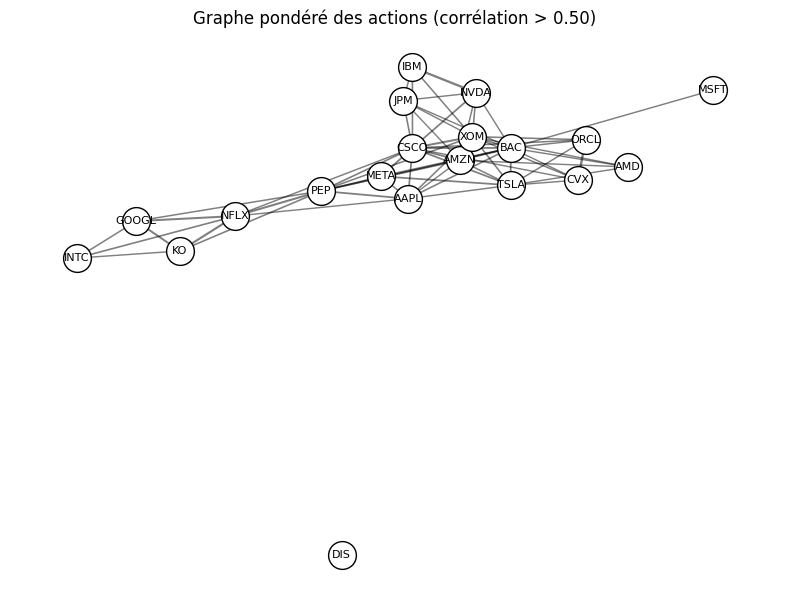

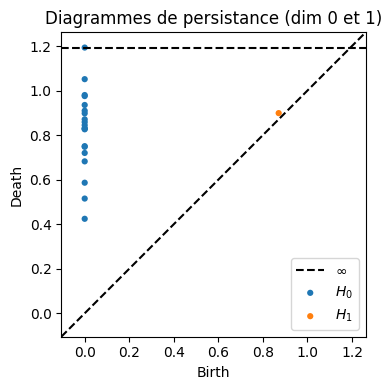

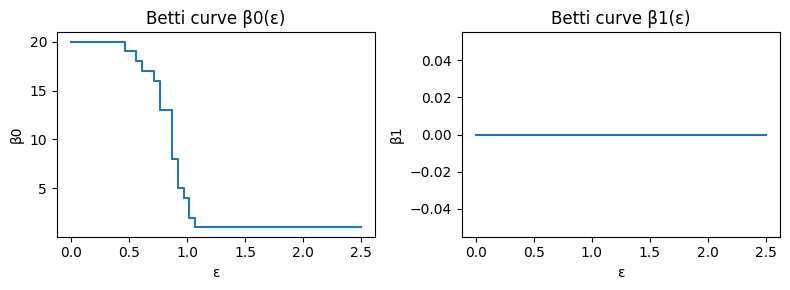

R² (test) horizon 5 jours : -0.1927
            date ticker     resid  ret_today  momentum       vol  topo_0  \
42755 2023-12-21    AMD  0.005865   0.018105  0.128283  0.027096    19.0   
42756 2023-12-21   CSCO  0.003732   0.016285  0.040989  0.007529    19.0   
42757 2023-12-21   ORCL -0.002096   0.007696 -0.108447  0.033227    19.0   
42758 2023-12-21    DIS  0.016911   0.029346 -0.030995  0.012906    19.0   
42759 2023-12-21    IBM -0.004150   0.004532  0.039118  0.006933    19.0   

          topo_1    topo_2  topo_3    topo_4    topo_5    y_true    y_pred  
42755  18.502706  1.237669     5.0  0.079698  0.031054  0.010801 -0.016029  
42756  18.502706  1.237669     5.0  0.079698  0.031054 -0.004070 -0.012707  
42757  18.502706  1.237669     5.0  0.079698  0.031054  0.017043 -0.015222  
42758  18.502706  1.237669     5.0  0.079698  0.031054 -0.023938 -0.012956  
42759  18.502706  1.237669     5.0  0.079698  0.031054 -0.017352 -0.012819  


In [ ]:


# =========================================================
# 1. CHARGEMENT DES DONNÉES
# =========================================================

data = yf.download(tickers, start=START_DATE, end=END_DATE)["Close"]
prices = data
returns = np.log(prices).diff().dropna()

N = len(tickers)

# =========================================================
# 2. FONCTIONS UTILES
# =========================================================

def compute_laplacian(corr_matrix: np.ndarray):
    """
    À partir d'une matrice de corrélation, construit :
    - W : matrice de poids (|corr|, diag à 0)
    - L : Laplacien L = D - W
    """
    W = np.abs(corr_matrix.copy())
    np.fill_diagonal(W, 0.0)
    degrees = W.sum(axis=1)
    D = np.diag(degrees)
    L = D - W
    return L, W

def laplacian_diffusion(x: np.ndarray, L: np.ndarray,
                        alpha: float, n_steps: int) -> np.ndarray:
    """
    h_{k+1} = h_k - alpha * L h_k
    Diffusion sur le graphe (lissage des rendements).
    """
    h = x.copy()
    for _ in range(n_steps):
        h = h - alpha * (L @ h)
    return h

def topo_features_from_corr(corr_matrix: np.ndarray, maxdim: int = 1) -> np.ndarray:
    """
    Transforme une matrice de corrélation en features topologiques.
    - distance d_ij = sqrt(2 * (1 - rho_ij))
    - homologie persistante (ripser, VR complex)
    - features : nb de points, persistance totale, max persistance
      pour dim 0 et dim 1.
    """
    Dmat = np.sqrt(2.0 * (1.0 - corr_matrix))
    np.fill_diagonal(Dmat, 0.0)

    res = ripser(Dmat, distance_matrix=True, maxdim=maxdim)
    dgms = res["dgms"]

    feats = []
    for dim in range(maxdim + 1):
        dgm = dgms[dim]
        finite_mask = np.isfinite(dgm[:, 1])
        dgm_finite = dgm[finite_mask]

        if dgm_finite.shape[0] == 0:
            feats.extend([0.0, 0.0, 0.0])
            continue

        lifetimes = dgm_finite[:, 1] - dgm_finite[:, 0]
        feats.extend([
            float(len(lifetimes)),        # nb de points
            float(lifetimes.sum()),       # persistance totale
            float(lifetimes.max()),       # max persistance
        ])
    return np.array(feats, dtype=float)

def compute_local_features(returns_df: pd.DataFrame,
                           k: int,
                           window_local: int) -> pd.DataFrame:
    """
    Calcule des features locales par action à la date k :
    - momentum k jours (somme des rendements sur window_local)
    - volatilité (écart-type sur window_local)
    """
    window = returns_df.iloc[k - window_local : k]
    mom = window.sum(axis=0)          # momentum
    vol = window.std(axis=0)          # volatilité
    feats = pd.DataFrame({
        "momentum": mom,
        "vol": vol
    })
    return feats

# =========================================================
# 3. VISU : GRAPHE + TOPO SUR UN JOUR
# =========================================================

def demo_visualisation(k_demo: int):
    window_demo = returns.iloc[k_demo - WINDOW_CORR : k_demo]
    R_demo = window_demo.corr().values

    L_demo, W_demo = compute_laplacian(R_demo)
    x_demo = returns.iloc[k_demo].values
    h_demo = laplacian_diffusion(x_demo, L_demo, alpha=ALPHA, n_steps=J_DIFF)
    e_demo = x_demo - h_demo

    # ---- Graphe pondéré (on filtre les arêtes faibles pour voir qqch)
    W_plot = W_demo.copy()
    W_plot[W_plot < EDGE_THRESHOLD] = 0.0

    G = nx.from_numpy_array(W_plot)
    mapping = {i: tickers[i] for i in range(N)}
    G = nx.relabel_nodes(G, mapping)

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42, k=0.3)
    edges, weights = zip(*nx.get_edge_attributes(G, "weight").items())

    nx.draw_networkx_nodes(G, pos, node_size=400, node_color="white", edgecolors="black")
    nx.draw_networkx_labels(G, pos, font_size=8)
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=np.array(weights)*2, alpha=0.5)

    plt.title("Graphe pondéré des actions (corrélation > {:.2f})".format(EDGE_THRESHOLD))
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    # ---- Diagrammes de persistance
    res_demo = ripser(np.sqrt(2*(1-R_demo)), distance_matrix=True, maxdim=1)
    dgms_demo = res_demo["dgms"]

    plt.figure(figsize=(6, 4))
    plot_diagrams(dgms_demo, show=False)
    plt.title("Diagrammes de persistance (dim 0 et 1)")
    plt.tight_layout()
    plt.show()

    # ---- Betti curves
    eps_grid = np.linspace(0, 2.5, 50)
    betti0, betti1 = [], []

    for eps in eps_grid:
        b0 = sum(1 for (b, d) in dgms_demo[0] if b <= eps < d)
        b1 = sum(1 for (b, d) in dgms_demo[1] if b <= eps < d)
        betti0.append(b0)
        betti1.append(b1)

    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    plt.step(eps_grid, betti0, where="post")
    plt.xlabel("ε"); plt.ylabel("β0")
    plt.title("Betti curve β0(ε)")

    plt.subplot(1, 2, 2)
    plt.step(eps_grid, betti1, where="post")
    plt.xlabel("ε"); plt.ylabel("β1")
    plt.title("Betti curve β1(ε)")
    plt.tight_layout()
    plt.show()

# Exemple : on visualise un jour au milieu de l'historique
k_demo = WINDOW_CORR + 200
demo_visualisation(k_demo)

# =========================================================
# 4. CONSTRUCTION DES FEATURES POUR LE MODELE
# =========================================================

feature_rows = []
targets = []

# on commence à max(WINDOW_CORR, WINDOW_LOCAL)
k_start = max(WINDOW_CORR, WINDOW_LOCAL)

for k in range(k_start, len(returns) - FORWARD_H):
    window_corr = returns.iloc[k - WINDOW_CORR : k]
    R = window_corr.corr().values

    # Laplacien / graphe
    L, _ = compute_laplacian(R)

    # rendements du jour t
    x_t = returns.iloc[k].values

    # diffusion laplacienne
    h_t = laplacian_diffusion(x_t, L, alpha=ALPHA, n_steps=J_DIFF)
    e_t = x_t - h_t  # résidus (mispricing local)

    # features topo globales
    topo_feats_t = topo_features_from_corr(R, maxdim=1)

    # features locales momentum + vol
    local_feats_t = compute_local_features(returns, k, WINDOW_LOCAL)

    # cible : rendement cumulé sur FORWARD_H jours
    future_rets = returns.iloc[k+1 : k+1+FORWARD_H].sum(axis=0).values

    date_t = returns.index[k]

    for i, ticker in enumerate(tickers):
        row = {
            "date": date_t,
            "ticker": ticker,
            "resid": e_t[i],
            "ret_today": x_t[i],
            "momentum": local_feats_t.loc[ticker, "momentum"],
            "vol": local_feats_t.loc[ticker, "vol"],
        }
        # on rajoute les features topo globales
        for j, val in enumerate(topo_feats_t):
            row[f"topo_{j}"] = val

        feature_rows.append(row)
        targets.append(future_rets[i])

features_df = pd.DataFrame(feature_rows)
y = np.array(targets, dtype=float)

feature_cols = [c for c in features_df.columns if c not in ["date", "ticker"]]
X = features_df[feature_cols].values

# =========================================================
# 5. MODELE RANDOM FOREST
# =========================================================

# split temporel 80/20 (sans shuffle)
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

model = RandomForestRegressor(
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("R² (test) horizon {} jours : {:.4f}".format(FORWARD_H, r2))

pred_df = features_df.iloc[split_idx:].copy()
pred_df["y_true"] = y_test
pred_df["y_pred"] = y_pred
print(pred_df.tail())


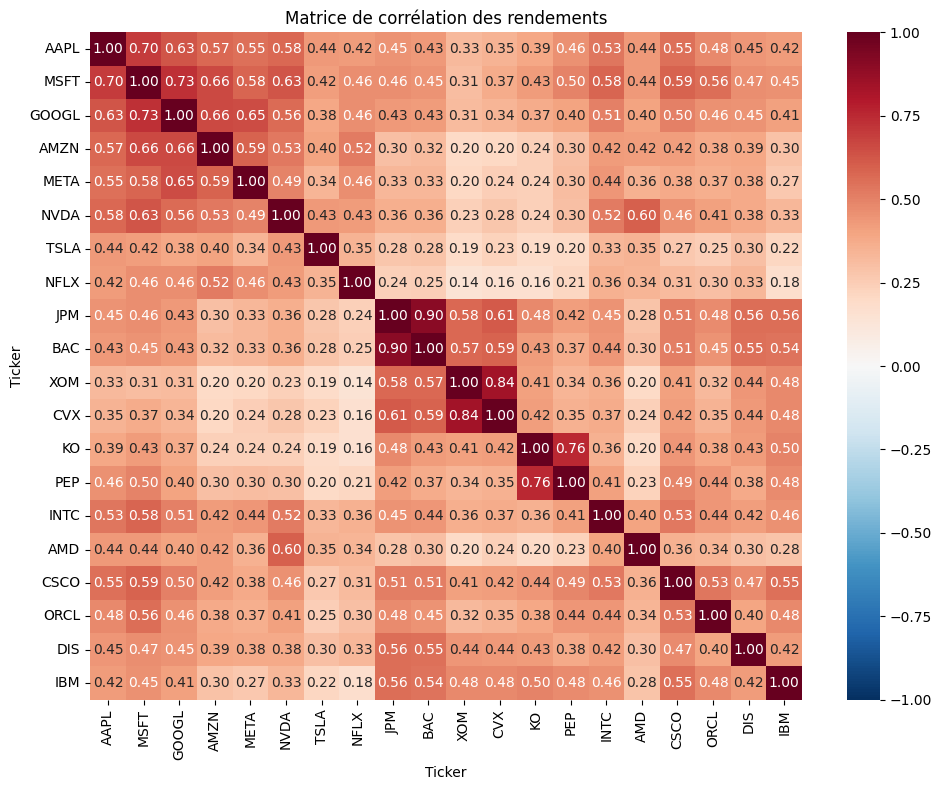

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# returns doit avoir les colonnes = tickers exactement
corr = returns[tickers].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",   # rouge pour positif, bleu pour négatif
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Matrice de corrélation des rendements")
plt.tight_layout()
plt.show()


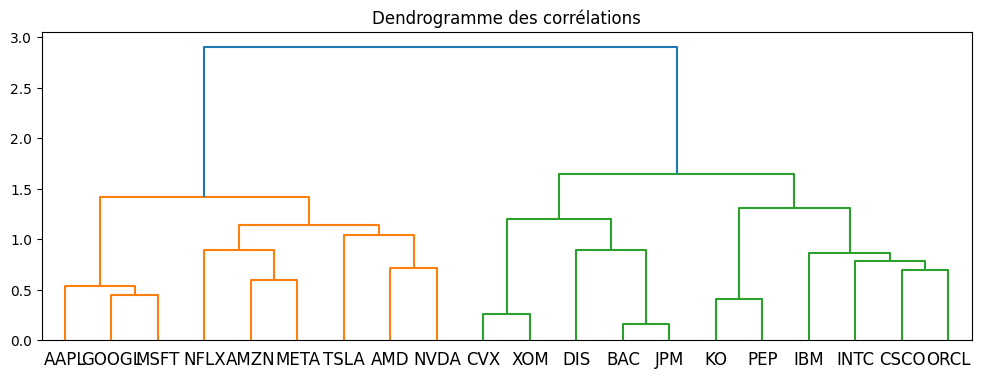

In [22]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(corr, method='ward')

plt.figure(figsize=(12,4))
dendrogram(Z, labels=corr.index)
plt.title("Dendrogramme des corrélations")
plt.show()


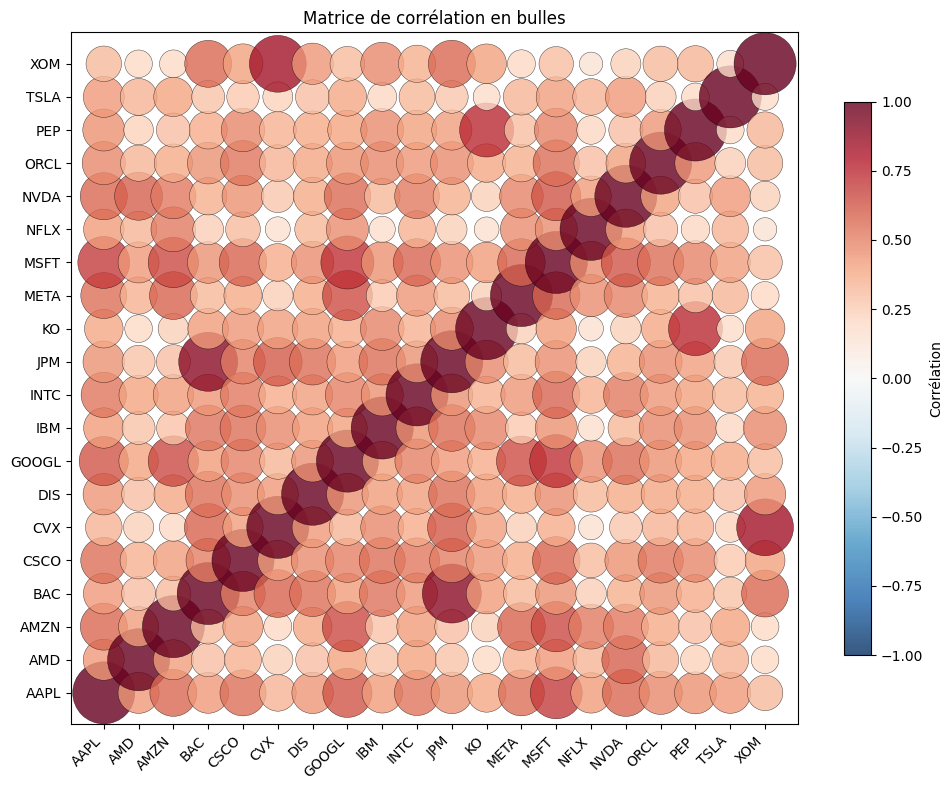

In [26]:
import matplotlib.pyplot as plt
import numpy as np

corr = returns.corr()
tickers = corr.columns.tolist()
n = len(tickers)

fig, ax = plt.subplots(figsize=(10, 8))

x, y, sizes, colors = [], [], [], []
for i in range(n):
    for j in range(n):
        x.append(i)
        y.append(j)
        val = corr.iloc[j, i]
        sizes.append(abs(val) * 2000)  # taille des bulles
        colors.append(val)

sc = ax.scatter(
    x, y,
    s=sizes,
    c=colors,
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    alpha=0.8,
    edgecolors="k",
    linewidths=0.3
)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(tickers, rotation=45, ha="right")
ax.set_yticklabels(tickers)

cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label("Corrélation")

plt.title("Matrice de corrélation en bulles")
plt.tight_layout()
plt.show()
